# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info(
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum())
print()
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? // Indica qué harías: ¿imputar, eliminar, ignorar?

  **RTA**
  
  La tabla *users* tiene las columnas:
  
  - city 469 datos faltantes y una proporcion del 11.72% // se investiga para imputar o dejar como nulos
  - churn_date 3534 datos faltantes y una proporcion del 88.35% // al ser un valor tan alto se ignora o elimina

  ---
  La tabla *usage* tiene las columnas:
  
  - date 50 datos faltantes y una proporcion del 1.2% // se investiga para imputar o dejar como nulos
  - duration 22076 datos faltantes y una proporcion del 55.19% // se investiga para imputar o dejar como nulos
  - length 17896 datos faltantes y una proporcion del 44.74% // se investiga para imputar o dejar como nulos
  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene una media y mediana de 11999.5 lo que quiere decir que hay una distribucion simetrica de los datos. 
  
- La columna `age` presenta una media de 33.73 alejada de la mediana 47.00, datos dispersos, ademas el valor minimo es -999.0 lo cual puede ser un error de escritura que debe analizarse detenidamente, la desviacion estanadar es alta en asi que los datos presentan mucha variabilidad.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` presentan promedios cercanos a la mediana, quiere decir que presentan una distribución simetrica, la std nos indica lo mismo ya que son pequeñas.
  
- Las columnas `duration` y `length` presentan una gran disminución en la cantidad (count) de datos lo que claramente afecta el resultado general del promedio, la media o la std. 

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

#users[columnas_user].describe(include='object')

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` cuenta con 3531 datos de 4000, faltan 469 datos, hay 7 tipos de ciudad y la top es Bogotá con una frecuencia de 808.
- La columna `plan` cuenta con atos completos, 2 categorias predominando Basico con una frecuencia de 

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

#usage['type'].describe()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` cuenta con datos completos, 2 categorias donde la de maxima frecuencia es text

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  // RTA: En la columna city del archivo users hay un sentinel '?' al que se le atribuyen 65 entradas y otro ' ' al que se le atribuyen 31.

- ¿Qué acción tomarías?
  // RTA: Ya que existen en la columna ciudad hay 7 categorias y hay dos que se representan como '?' del plan basico y '?' del plan premium, teniendo en cuenta que las otras ciudades cuentan cada una con etiqueta de basico y primum esta ciudad faltante debe revisarse bien para encontrar el nombre ya que teniendo las dos categorias puedo inferir que corresponden a la misma ciudad.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se extrajo años y la cantidad de veces que aparece cada uno, en user hay 4 años diferentes incluyendo el 2026

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, en este caso este archivo solo contiene datos del año 2024  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  * RTA: En user hay 40 registros del año 2026, los otros años se muestran con normalidad del 2022 al 2024 
- ¿Qué harías con ellas?
  * RTA: los eliminaria ya que el porcentaje de estos datos no es significativo.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace([-999], pd.NA)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace(['?', ' '], pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year != 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              1330
unique                             1330
top       2024-08-11 23:36:14.043510880
freq                                  1
first               2024-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Resultados generales:
- Duration: 0% nulos en calls, 99.93% nulos en texts
- Length: 99.93% nulos en calls, 0% nulos en texts

Diagnostico de nulos en `duration`: 
- Los porcentajes varian demasiado entre tipos, por lo que se puede deducir que los nulos en duration dependen completamente del tipo de comunicación,  de la variable type y son MAR

Diagnostico de nulos en `length`
- Los porcentajes varian demasiado entre tipos, por lo que se puede deducir que los nulos en length dependen completamente del tipo de comunicación, de la variable type y son MAR

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage['total_minutos'] = (usage['duration']/60) #conocer el total de minutos en llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text": 'sum',
    "is_call": 'sum',
    'total_minutos': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,total_minutos
0,10000,7,3,0.395
1,10001,5,10,0.553
2,10002,5,2,0.179


In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,0.395
1,10001,5,10,0.553
2,10002,5,2,0.179


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='outer')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,NaT,Basico,NaN,7.0,3.0,0.395000
1,10001,Mateo,Torres,53.0,<NA>,NaT,Basico,NaN,5.0,10.0,0.553000
2,10002,Sofia,Ramirez,57.0,CDMX,NaT,Basico,NaN,5.0,2.0,0.179000
3,10003,Mateo,Ramirez,69.0,Bogotá,NaT,Premium,NaN,11.0,3.0,0.149833
4,10004,Mateo,Torres,63.0,GDL,NaT,Basico,NaN,4.0,3.0,0.133500


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,0.388618
std,17.689919,2.358416,2.144238,0.302802
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,0.185333
50%,48.000000,5.000000,4.000000,0.329667
75%,63.000000,7.000000,6.000000,0.523583
max,79.000000,17.000000,15.000000,2.594833


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

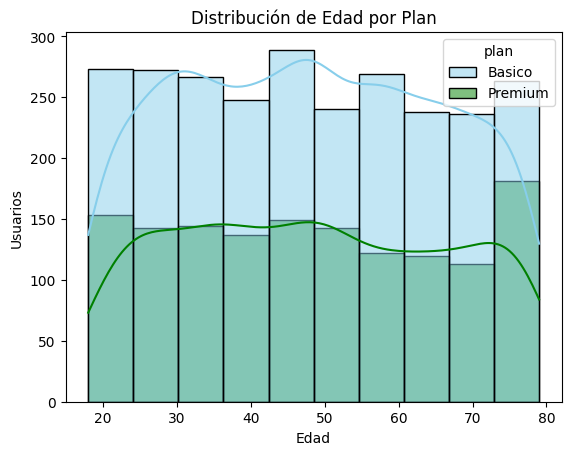

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', bins=10, hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Edad')
plt.ylabel('Usuarios')
plt.title('Distribución de Edad por Plan')
plt.show()


💡Insights: 
- Plan Basico: la distribucion de edades es simetrica, el histograma tambien revela que para cada edad dentro de este plan se superan los dos usuarios
- Plan Premium: puede decirse que la distribucion de edades es aún más simetrica que en el plan básico a excepción del rango de edad de 75 a 78-79 años que superan en cantidad de usuarios a las demas edades de este tipo de plan, lo cual demuestra que adultos mayores pueden considerarse clientes de alto valor o VIP. 

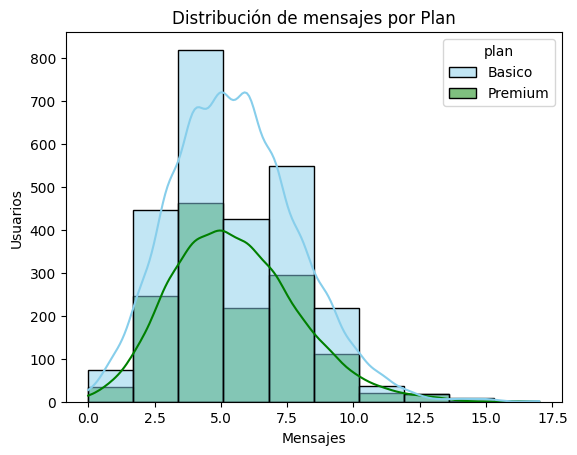

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Mensajes')
plt.ylabel('Usuarios')
plt.title('Distribución de mensajes por Plan')
plt.show()


💡Insights: 
La distribucipon de ambos planes esta sesgada a derecha, lo que quiere decir que son pocos los usuarios que hacen uso de muchos mensajes, tambien podemos decir que en el plan Basico mas de 800 usuarios disponen de entre 3 a 5 mensajes y en el plan premium más de 400 usuarios, lo cual no es un valor alto en general, este podria ser un indicador importante para entender el comportamiento del cliente frente al uso de mensajes, entiendo que las redes sociales facilitan la comunicación instantanea, por lo tanto el uso de este tipo de mensajeria se usa más.

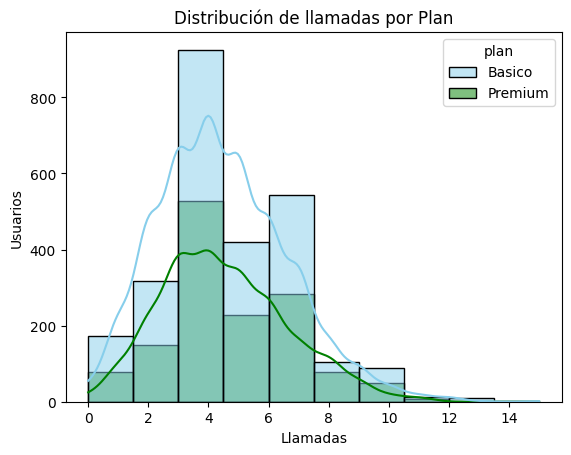

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Llamadas')
plt.ylabel('Usuarios')
plt.title('Distribución de llamadas por Plan')
plt.show()

💡Insights: Ambos planes muestran una distibución sesgada a la derecha, en el plan basico mas de 800 usuarios usan de 3-4 llamadas telefonicas y en el plan premium mas de 500 usuarios usan de 3-4 llamadas, pero es evidente que son muy pocos los usuarios que usan este servicio de más de 10 veces, lo cual puede verse afectado por las llamadas integradas en las redes sociales.


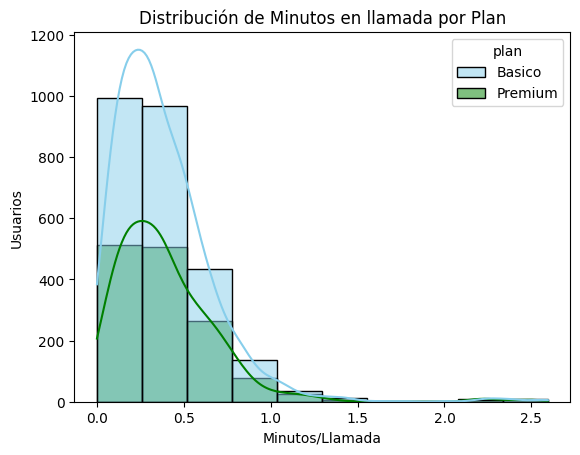

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Minutos/Llamada')
plt.ylabel('Usuarios')
plt.title('Distribución de Minutos en llamada por Plan')
plt.show()

💡Insights: Nuevamente el sesgo es a la derecha para los dos planes 'basico' y 'premium', la duración de las llamadas es muy corta

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

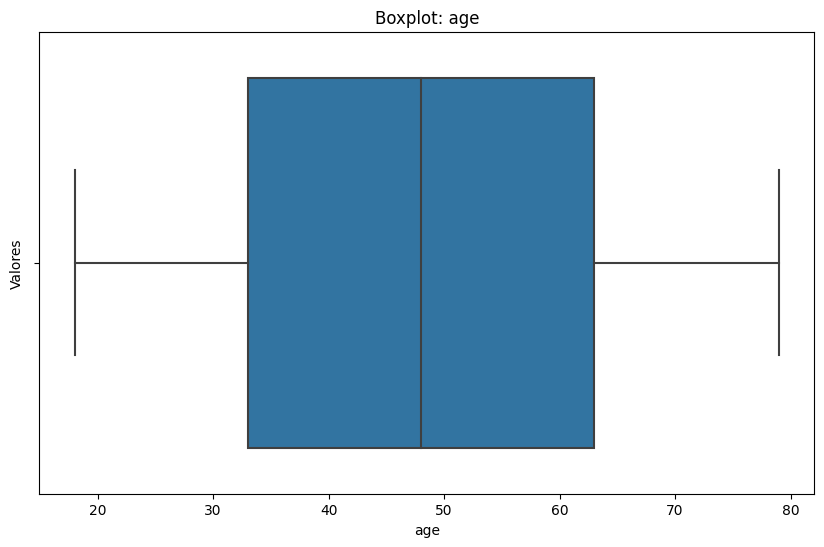

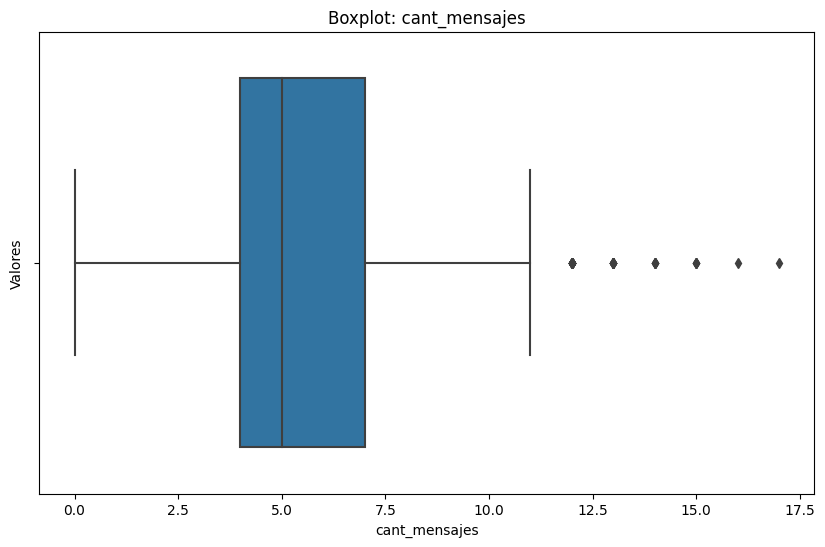

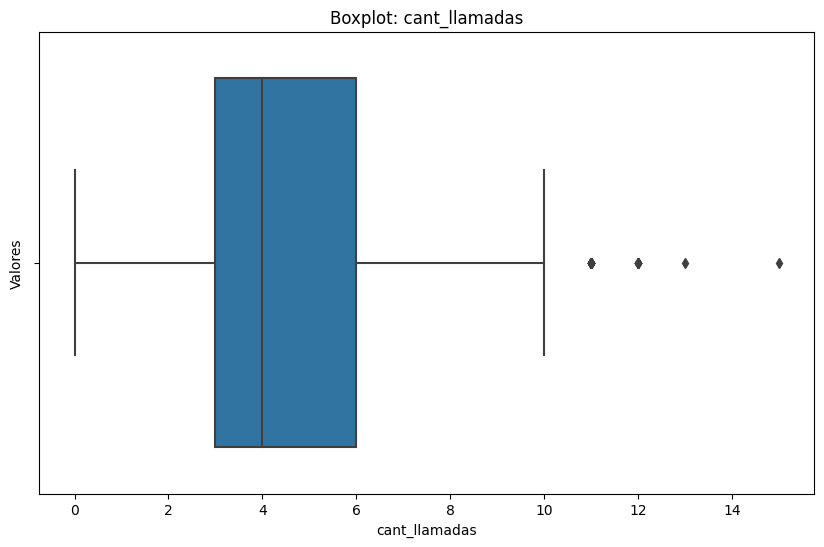

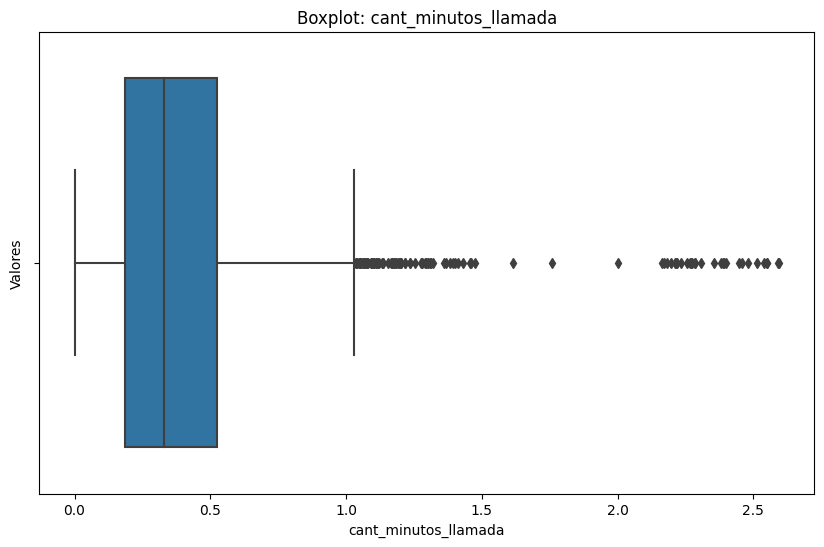

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Bucle for para crear un boxplot por cada columna numerica
for col in columnas_numericas:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.ylabel('Valores')
    plt.show()
    


💡Insights: 

- Age: No presenta outliers quiere decir que no hay valores extremos que se alejen mucho del resto, la mediana esta en valores centrales indicando que la mayoria de las edades se encuentran entre los 35 y 65 años.
  
- cant_mensajes: la mediana (5) esta por debajo de la mitad del rango de los datos de medida, los puntos aislados a la derecha son outliers altos (11 - 17), que revelan una cola derecha larga y mayor uso de los mensajes de texto.

- cant_llamadas: la mediana (4) esta por debajo de la mitad del rango de los datos de medida, los puntos aislados a la derecha son outliers altos (11 - 15) tambien revelan una
cola derecha larga y mayor uso de llamadas.

- cant_minutos_llamada: Este boxplot presenta muchos más outliers que los demas, por un lado la mediana está en valores bajos menos 0.5 min de duración, por otro lado la caja (IQR) es más estrecha que las demás entendiendo que la mayoría de las duraciones de las llamadas están concentradas en un rango reducido, la distribución asimetrica d elos bigotes tambien muestra el sesgo a la derecha, y fuera de ellos se puede observar que hay una cantidad considerable de outliers, que si nien no representa la mayoria de los datos si nos muestra que hay carias llamadas con duraciones entre 1 - 2.5 minutos.

In [64]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Procesar col individualmente
for col in columnas_limites:
    print(f"\n--- Analizando columna: {col} ---")

    # Q1 
    Q1 = user_profile[col].quantile(0.25) 
    print(f'Q1: {Q1}')

    # Q3
    Q3 = user_profile[col].quantile(0.75)
    print(f'Q3: {Q3}')

    # IQR
    IQR = Q3 - Q1
    print(f'IQR: {IQR}')

    # Limites para deteccion de outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')


--- Analizando columna: cant_mensajes ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

--- Analizando columna: cant_llamadas ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

--- Analizando columna: cant_minutos_llamada ---
Q1: 0.18533333333333335
Q3: 0.5235833333333333
IQR: 0.33824999999999994
Límite inferior: -0.32204166666666656
Límite superior: 1.0309583333333332


In [62]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,0.388618
std,2.358416,2.144238,0.302802
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,0.185333
50%,5.000000,4.000000,0.329667
75%,7.000000,6.000000,0.523583
max,17.000000,15.000000,2.594833


💡Insights: 
- Para las 3 columnas del analisis: cant_mensajes, cant_llamadas, cant_minutos_llamada, los datos pueden normales y deberse al comportamiento propio de los clientes, no inusual que por ejemplo un cliente envie 17 mensajes o realice 15 llamadas ya que pueden ser usuarios activos, depende del uso del plan si es empresarial o personal, si es joven o adulto como se muestra en insights anteriores, o a multiples variables, por esta razon considero que lo mejor en este caso es mantenerlos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [54]:

# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_mensajes'] < 5) & (user_profile['cant_llamadas'] < 5), 'Bajo uso',
        np.where((user_profile['cant_mensajes'] < 10) & (user_profile['cant_llamadas'] < 10), 'Uso medio',
             'Alto uso',
                     )
                )
user_profile[['grupo_uso']].head(10)

,grupo_uso
0,Uso medio
1,Alto uso
2,Uso medio
3,Alto uso
4,Bajo uso
5,Uso medio
6,Uso medio
7,Uso medio
8,Uso medio
9,Uso medio


In [55]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,NaT,Basico,NaN,7.0,3.0,0.395000,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,NaT,Basico,NaN,5.0,10.0,0.553000,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,NaT,Basico,NaN,5.0,2.0,0.179000,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,NaT,Premium,NaN,11.0,3.0,0.149833,Alto uso
4,10004,Mateo,Torres,63.0,GDL,NaT,Basico,NaN,4.0,3.0,0.133500,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [56]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30), 'Joven',
        np.where((user_profile['age'] < 60), 'Adulto',
             'Adulto Mayor',
                     )
                )
user_profile[['grupo_uso']].head(10)

,grupo_uso
0,Uso medio
1,Alto uso
2,Uso medio
3,Alto uso
4,Bajo uso
5,Uso medio
6,Uso medio
7,Uso medio
8,Uso medio
9,Uso medio


In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,NaT,Basico,NaN,7.0,3.0,0.395000,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,NaT,Basico,NaN,5.0,10.0,0.553000,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,NaT,Basico,NaN,5.0,2.0,0.179000,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,NaT,Premium,NaN,11.0,3.0,0.149833,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,NaT,Basico,NaN,4.0,3.0,0.133500,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

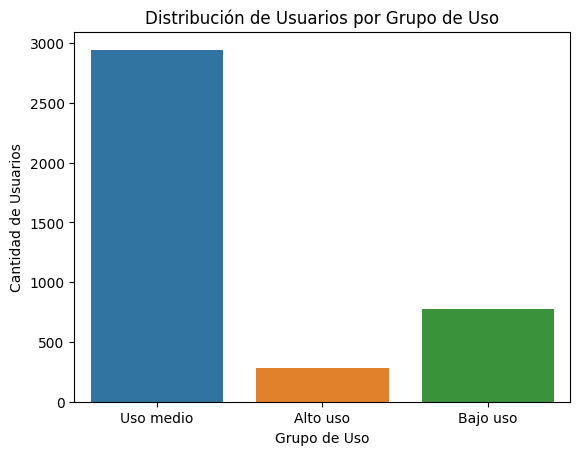

In [58]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()   

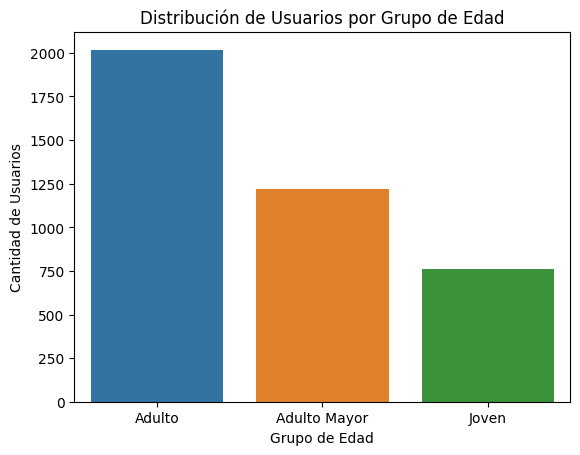

In [59]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?



- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Originalmente teníamos 3 tablas de datos, en las cuales se encontraron problemas como: datos faltantes en proporciones de hasta 88.35%, también se presentan sentinels como -999, datos numéricos en formato de texto o datos de fecha en formato incorrecto.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
 **Rta:**  Se identificaron los siguientes segmentos de cliente según su uso; Bajo uso, Uso medio y Alto uso, para edad los siguientes segmentos; Joven, Adulto y Adulto Mayor.

🔍 **Segmentos por Edad**
- Los adultos componen la mayoría de usuarios llegando a los 2000, los adultos mayores alrededor de 1250 usuarios y jovenes 750 usuarios


📊 **Segmentos por Nivel de Uso**
- Alrededor de 2900 usuarios corresponden al segmento Uso medio, mientras menos de 500 usuarios son de Alto uso, menos de 1000 usuarios son de bajo uso.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
**Rta**
Los segmentos más valiosos en el caso de usuarios por grupo de edad son los adultos, ya que representan la mayoría, por esta razón las campañas de marketing pueden tener un enfoque que resulte atractivo para este grupo de edad, sin embargo, los adultos mayores también representan una cantidad considerable para la cual se podrían priorizar campañas especiales que cubran esta categoría.
En cuanto al uso el segmento que presenta una gran mayoría en el uso de mensajearía y llamadas telefónicas es de uso medio, se puede reforzar a través de campañas de marketing el uso de las mismas, tambien resulta interesante que el uso en general de estos servicios de telefonia es poco habitual, siento 17 la cantidad maxima de mensajes y 15 la de llamadas,  seria importante analizar el uso de mensajeria instantanea como Whatsapp o Messenger integrado en redes sociales como Facebook, al igual que las llamadas de video o llamas de voz que ofrecen estas redes, el uso de estas puede estar limitando el uso de los servicios telefónicos como llamadas y mensajes de texto.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
**Rta**
los patrones de uso extremo corresponden a uso de mensajería en un máximo de 17 mensajes de texto, lo cual no resulta un numero difícil de creer, puede deberse a diferentes factores, el cliente, la edad, si el uso es personal o comercial, si quizá es una persona activa socialmente entre otras muchas variables, al igual que el patrón de llamadas con un máximo de 15

💡 **Recomendaciones**
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
**Rta**
Realmente considero que mejorar la oferta no resulta del todo atractivo si bien los planes pueden contener mensajería y llamadas ilimitadas el problema no esta en el plan, sino en el uso que dan los usuarios, yo volvaria mi enfoque al uso de datos mobiles, velocidad de navegación y otras cosas que resulten atractivas y que sean de mayor uso para los clientes, ya que si por ejemplo me encuentro del otro lado del mundo es más factible para mi realizar una video llamada via whatsapp u otra red social que ofrezca el mismo servicio, antes que usar una llamada telefonica que me pueda generar gastos extra en mi factura, por ello cambiaria el enfoque de las estrategias.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`